# GitHub Repositories Analysis
## Comprehensive Analysis of Top Repositories Across Domains

**Author:** Sitt Min Thar
**Date:** March 2026
**Purpose:** Analyze trends, characteristics, and patterns in top GitHub repositories

This notebook provides a deep dive into the current state of popular GitHub repositories, examining key metrics, programming languages, domains, and growth patterns across different categories. Special attention is given to high-performing projects like NVIDIA's repositories.

## Setup Instructions

Before running this notebook, please install the required packages if you haven't already:

```bash
# Install required packages
!pip install pandas numpy matplotlib seaborn plotly scikit-learn
```

In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Try importing plotly with error handling
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    plotly_available = True
except ImportError:
    print("Plotly is not available. Some interactive visualizations will be skipped.")
    plotly_available = False
    px = None
    go = None
    make_subplots = None

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#000000',
    'axes.facecolor': '#000000',
    'grid.color': '#222222',
    'axes.edgecolor': '#333333',
    'text.color': '#FFFFFF',
    'axes.labelcolor': '#CCCCCC',
    'xtick.color': '#888888',
    'ytick.color': '#888888'
})
sns.set_palette("magma")
%matplotlib inline

In [2]:
# Load the dataset
df = pd.read_csv('github_top_repositories.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (3000, 21)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Domain             3000 non-null   str  
 1   Repository Name    3000 non-null   str  
 2   Full Name          3000 non-null   str  
 3   Description        2994 non-null   str  
 4   Primary Language   2746 non-null   str  
 5   Stars Count        3000 non-null   int64
 6   Forks Count        3000 non-null   int64
 7   Watchers Count     3000 non-null   int64
 8   Open Issues Count  3000 non-null   int64
 9   Has Wiki           3000 non-null   bool 
 10  Has Pages          3000 non-null   bool 
 11  Has Projects       3000 non-null   bool 
 12  Size (KB)          3000 non-null   int64
 13  Created At         3000 non-null   str  
 14  Updated At         3000 non-null   str  
 15  Pushed At          3000 non-null   str  
 16  Default Branch     3000 non-nu

,Domain,Repository Name,Full Name,Description,Primary Language,Stars Count,Forks Count,Watchers Count,Open Issues Count,Has Wiki,...,Has Projects,Size (KB),Created At,Updated At,Pushed At,Default Branch,Owner Login,Owner Type,License,Topics
0,Machine Learning,tensorflow,tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,194126,75247,194126,3715,False,...,True,1288956,2015-11-07T01:19:20Z,2026-03-14T00:28:29Z,2026-03-14T01:48:00Z,master,tensorflow,Organization,Apache License 2.0,"deep-learning, deep-neural-networks, distribut..."
1,Machine Learning,transformers,huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,157772,32464,157772,2282,True,...,True,453964,2018-10-29T13:56:00Z,2026-03-14T01:38:18Z,2026-03-13T23:15:04Z,main,huggingface,Organization,Apache License 2.0,"audio, deep-learning, deepseek, gemma, glm, ha..."
2,Machine Learning,prompts.chat,f/prompts.chat,"f.k.a. Awesome ChatGPT Prompts. Share, discove...",HTML,152186,19999,152186,28,True,...,True,231182,2022-12-05T13:54:13Z,2026-03-14T02:08:32Z,2026-03-13T14:06:54Z,main,f,User,Creative Commons Zero v1.0 Universal,"ai, artificial-intelligence, awesome-list, cha..."
3,Machine Learning,pytorch,pytorch/pytorch,Tensors and Dynamic neural networks in Python ...,Python,98216,27194,98216,18055,True,...,True,1273608,2016-08-13T05:26:41Z,2026-03-14T01:40:49Z,2026-03-14T02:08:49Z,main,pytorch,Organization,Other,"autograd, deep-learning, gpu, machine-learning..."
4,Machine Learning,LLMs-from-scratch,rasbt/LLMs-from-scratch,Implement a ChatGPT-like LLM in PyTorch from s...,Jupyter Notebook,87955,13422,87955,1,False,...,False,15703,2023-07-23T18:15:57Z,2026-03-14T02:06:45Z,2026-03-07T23:05:50Z,main,rasbt,User,Other,"ai, artificial-intelligence, chatbot, chatgpt,..."


In [3]:
# Convert date columns to datetime
date_columns = ['Created At', 'Updated At', 'Pushed At']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], utc=True)

# Basic statistics of the dataset
df.describe(include='all')

,Domain,Repository Name,Full Name,Description,Primary Language,Stars Count,Forks Count,Watchers Count,Open Issues Count,Has Wiki,...,Has Projects,Size (KB),Created At,Updated At,Pushed At,Default Branch,Owner Login,Owner Type,License,Topics
count,3000,3000,3000,2994,2746,3000.000000,3000.000000,3000.000000,3000.000000,3000,...,3000,3.000000e+03,3000,3000,3000,3000,3000,3000,2691,2793
unique,15,2526,2562,2554,54,NaN,NaN,NaN,NaN,2,...,2,NaN,NaN,NaN,NaN,69,2185,2,21,2353
top,Machine Learning,cli,keras-team/keras,Deep Learning for humans,Python,NaN,NaN,NaN,NaN,True,...,True,NaN,NaN,NaN,NaN,master,microsoft,Organization,MIT License,"android, java"
freq,200,7,4,4,605,NaN,NaN,NaN,NaN,1917,...,2237,NaN,NaN,NaN,NaN,1586,41,1885,898,6
mean,NaN,NaN,NaN,NaN,NaN,20783.222667,3325.095667,20783.222667,398.147000,NaN,...,NaN,2.959861e+05,2018-04-05 06:39:59.232000+00:00,2026-03-11 17:22:33.371666+00:00,2025-06-19 04:30:30.037666+00:00,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,109.000000,4.000000,109.000000,0.000000,NaN,...,NaN,2.000000e+00,2008-09-02 05:34:33+00:00,2024-11-01 00:54:36+00:00,2016-03-09 11:44:35+00:00,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,6359.250000,677.000000,6359.250000,20.000000,NaN,...,NaN,7.420750e+03,2015-10-05 22:47:03+00:00,2026-03-13 05:23:07+00:00,2024-12-09 09:43:37+00:00,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,14231.000000,1755.000000,14231.000000,109.500000,NaN,...,NaN,3.832000e+04,2018-02-10 01:04:54+00:00,2026-03-13 19:03:16.500000+00:00,2026-02-28 19:02:11.500000+00:00,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,25784.000000,3754.000000,25784.000000,381.250000,NaN,...,NaN,1.598460e+05,2020-12-11 21:03:41.500000+00:00,2026-03-14 00:34:47+00:00,2026-03-13 10:16:56.250000+00:00,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,409518.000000,75247.000000,409518.000000,18055.000000,NaN,...,NaN,6.183846e+07,2026-03-06 22:00:43+00:00,2026-03-14 02:23:25+00:00,2026-03-14 02:23:17+00:00,NaN,NaN,NaN,NaN,NaN


In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Description           6
Primary Language    254
License             309
Topics              207
dtype: int64


# 1. Dataset Overview & Key Metrics

In [5]:
# Key metrics
total_repos = len(df)
unique_domains = df['Domain'].nunique()
unique_languages = df['Primary Language'].nunique()
total_stars = df['Stars Count'].sum()
avg_stars = df['Stars Count'].mean()
median_stars = df['Stars Count'].median()

print(f"Total Repositories in Dataset: {total_repos:,}")
print(f"Domains Covered: {unique_domains}")
print(f"Programming Languages: {unique_languages}")
print(f"Total Stars Across All Repos: {total_stars:,}")
print(f"Average Stars Per Repo: {avg_stars:,.0f}")
print(f"Median Stars Per Repo: {median_stars:,.0f}")

# Most common domains
top_domains = df['Domain'].value_counts()
print(f"\nDomains Distribution:")
for idx, (domain, count) in enumerate(top_domains.items(), 1):
    print(f"{idx}. {domain}: {count:,} repositories")

Total Repositories in Dataset: 3,000
Domains Covered: 15
Programming Languages: 54
Total Stars Across All Repos: 62,349,668
Average Stars Per Repo: 20,783
Median Stars Per Repo: 14,231

Domains Distribution:
1. Machine Learning: 200 repositories
2. Deep Learning: 200 repositories
3. Python: 200 repositories
4. JavaScript: 200 repositories
5. Java: 200 repositories
6. C++: 200 repositories
7. Go: 200 repositories
8. Rust: 200 repositories
9. Data Science: 200 repositories
10. Web Development: 200 repositories
11. Android: 200 repositories
12. iOS: 200 repositories
13. Blockchain: 200 repositories
14. Cybersecurity: 200 repositories
15. DevOps: 200 repositories


# 2. Domain Distribution Analysis

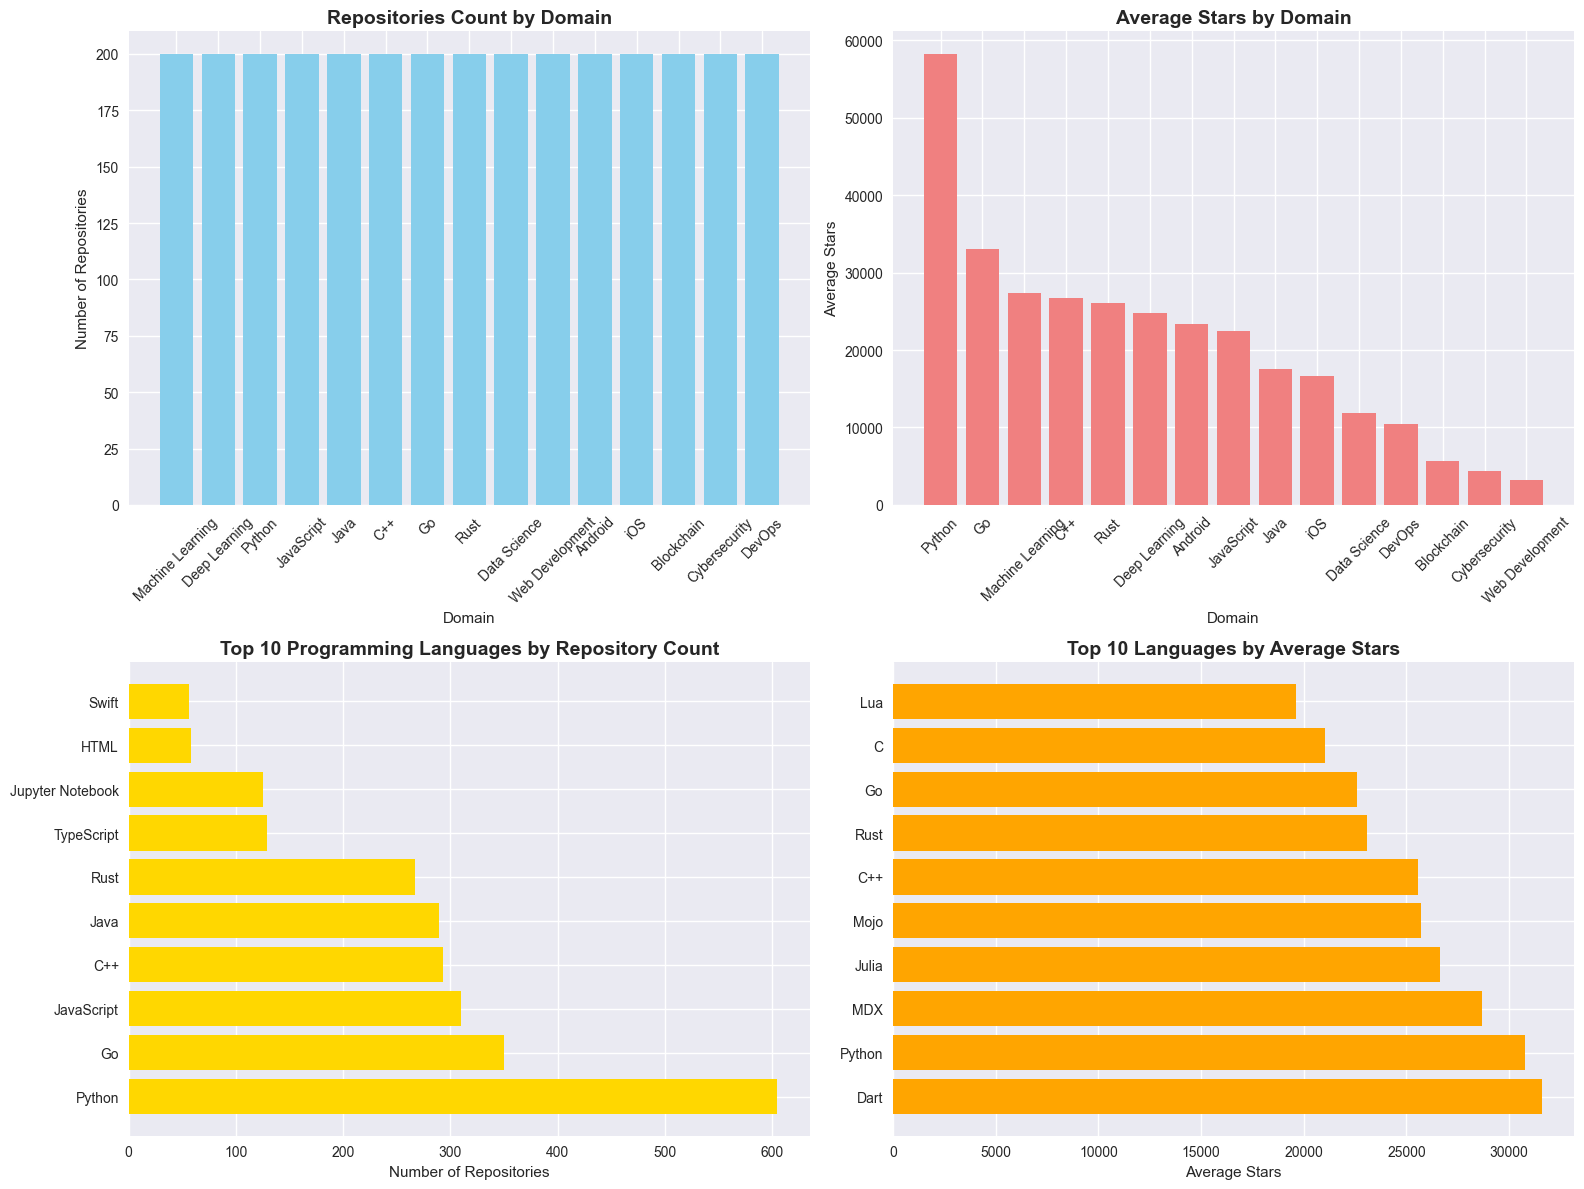

In [6]:
# Domain distribution
domain_counts = df['Domain'].value_counts()

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top domains by repository count
axes[0,0].bar(domain_counts.index, domain_counts.values, color='skyblue')
axes[0,0].set_title('Repositories Count by Domain', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Domain')
axes[0,0].set_ylabel('Number of Repositories')
axes[0,0].tick_params(axis='x', rotation=45)

# Average stars by domain
stars_by_domain = df.groupby('Domain')['Stars Count'].mean().sort_values(ascending=False)
axes[0,1].bar(stars_by_domain.index, stars_by_domain.values, color='lightcoral')
axes[0,1].set_title('Average Stars by Domain', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Domain')
axes[0,1].set_ylabel('Average Stars')
axes[0,1].tick_params(axis='x', rotation=45)

# Top languages by repo count
lang_counts = df['Primary Language'].value_counts().head(10)
axes[1,0].barh(range(len(lang_counts)), lang_counts.values, color='gold')
axes[1,0].set_yticks(range(len(lang_counts)))
axes[1,0].set_yticklabels(lang_counts.index)
axes[1,0].set_title('Top 10 Programming Languages by Repository Count', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Number of Repositories')

# Average stars by language (top 10)
stars_by_lang = df.groupby('Primary Language')['Stars Count'].mean().sort_values(ascending=False).head(10)
axes[1,1].barh(range(len(stars_by_lang)), stars_by_lang.values, color='orange')
axes[1,1].set_yticks(range(len(stars_by_lang)))
axes[1,1].set_yticklabels(stars_by_lang.index)
axes[1,1].set_title('Top 10 Languages by Average Stars', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Average Stars')

plt.tight_layout()
plt.show()

# 3. Repository Popularity Metrics Analysis

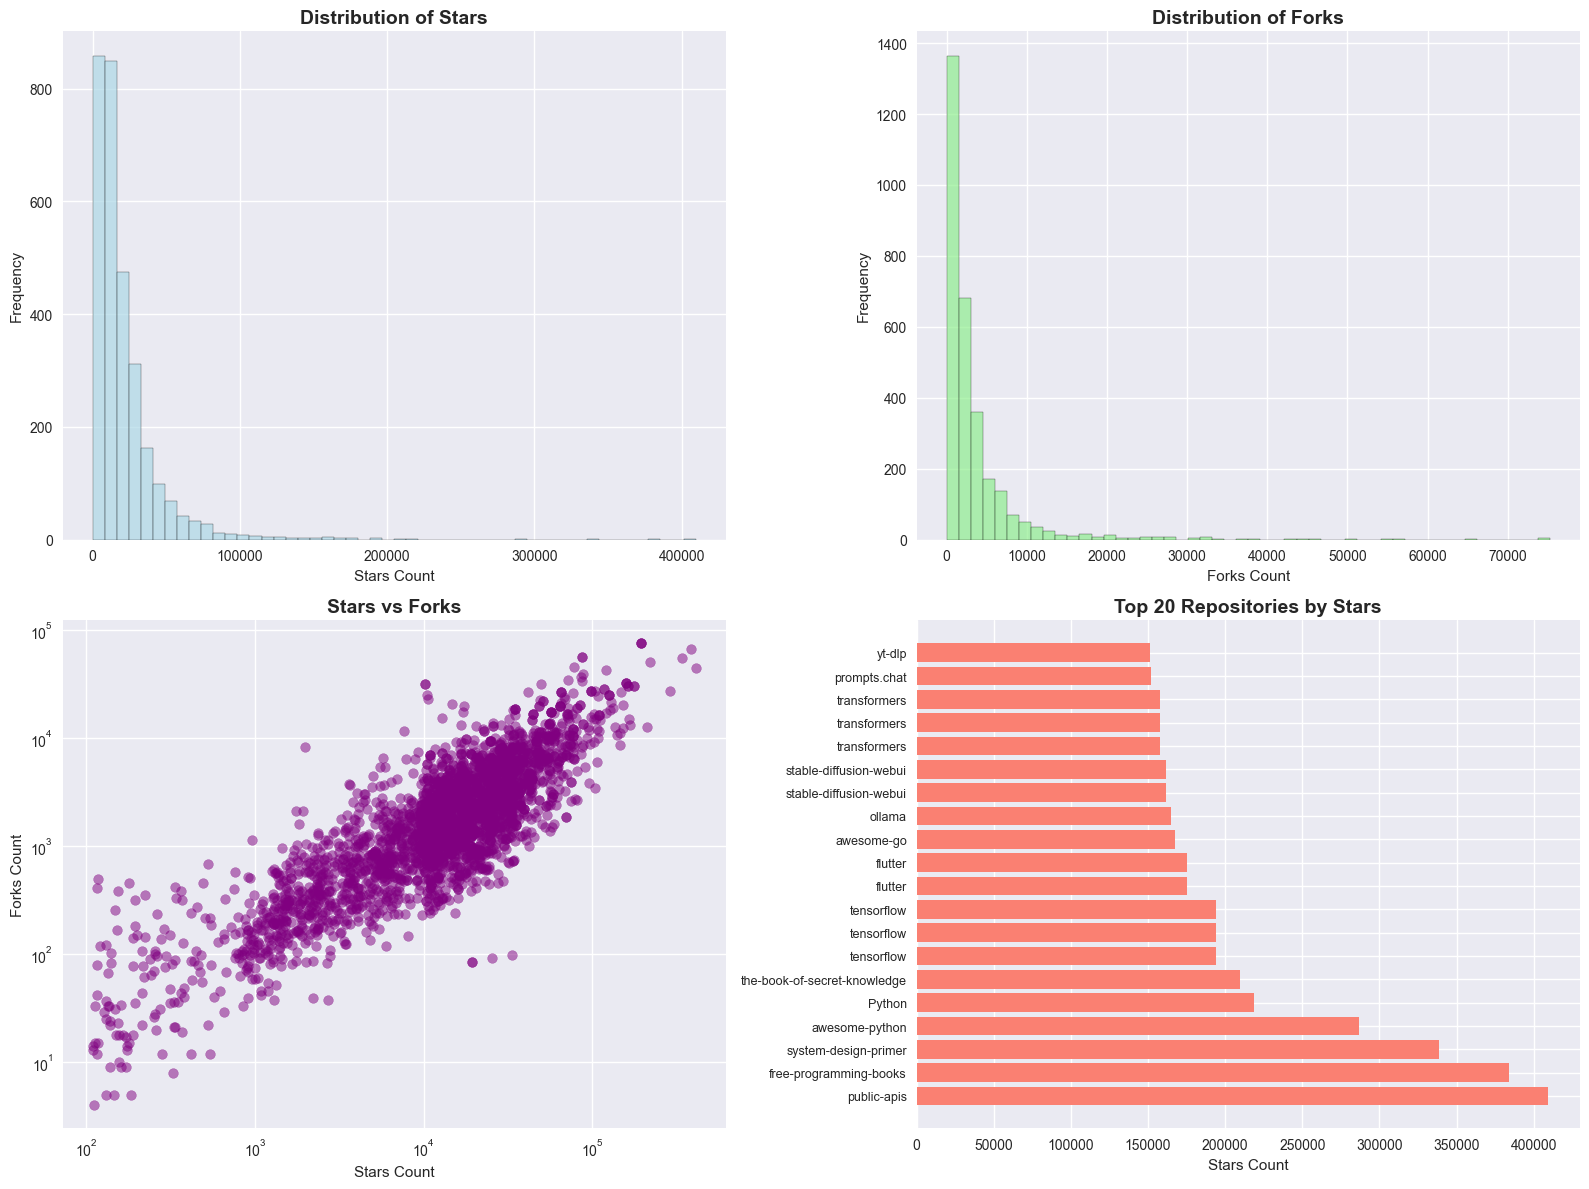

In [7]:
# Repository metrics analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution of stars
axes[0,0].hist(df['Stars Count'], bins=50, edgecolor='black', alpha=0.7, color='lightblue')
axes[0,0].set_title('Distribution of Stars', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Stars Count')
axes[0,0].set_ylabel('Frequency')

# Distribution of forks
axes[0,1].hist(df['Forks Count'], bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0,1].set_title('Distribution of Forks', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Forks Count')
axes[0,1].set_ylabel('Frequency')

# Relationship between stars and forks
axes[1,0].scatter(df['Stars Count'], df['Forks Count'], alpha=0.5, color='purple')
axes[1,0].set_title('Stars vs Forks', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Stars Count')
axes[1,0].set_ylabel('Forks Count')
axes[1,0].set_xscale('log')
axes[1,0].set_yscale('log')

# Top 20 repositories by stars
top_20_repos = df.nlargest(20, 'Stars Count')
axes[1,1].barh(range(len(top_20_repos)), top_20_repos['Stars Count'], color='salmon')
axes[1,1].set_yticks(range(len(top_20_repos)))
axes[1,1].set_yticklabels([name.split('/')[-1] for name in top_20_repos['Full Name']], fontsize=9)
axes[1,1].set_title('Top 20 Repositories by Stars', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Stars Count')

plt.tight_layout()
plt.show()

# 4. Repository Activity Analysis

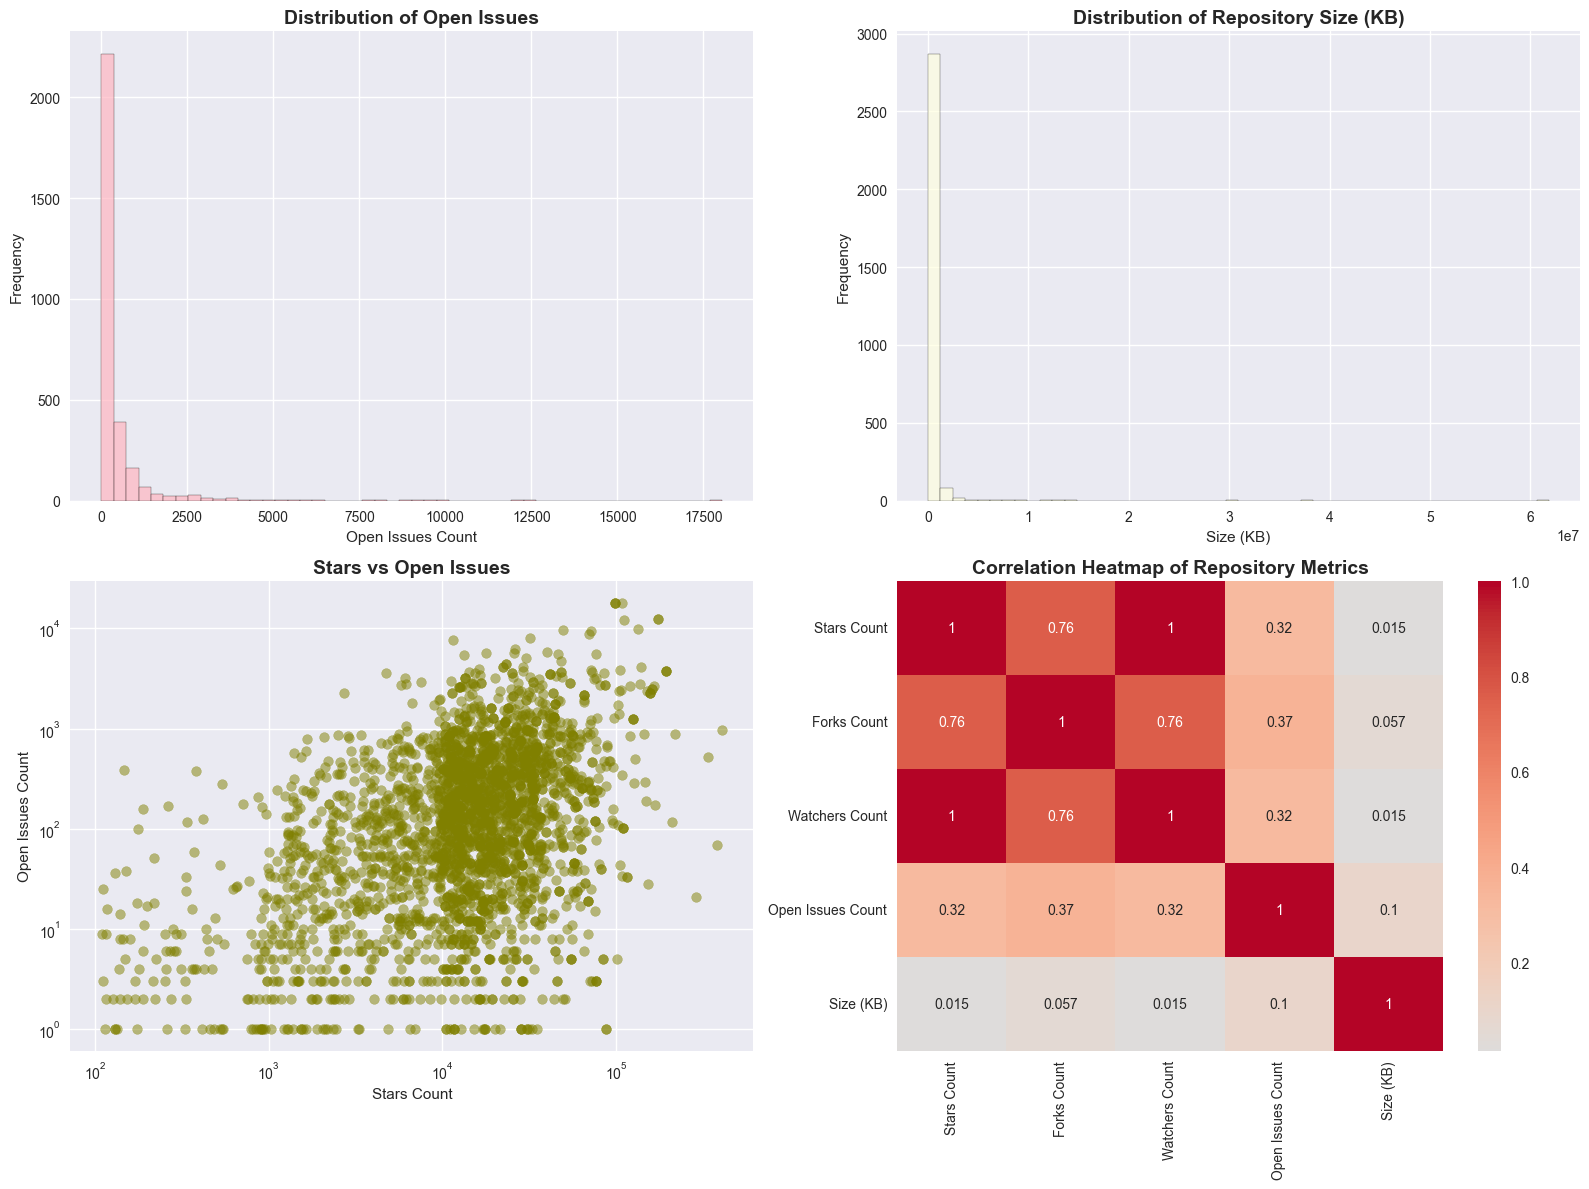

In [8]:
# Activity metrics analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Open issues distribution
axes[0,0].hist(df['Open Issues Count'], bins=50, edgecolor='black', alpha=0.7, color='lightpink')
axes[0,0].set_title('Distribution of Open Issues', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Open Issues Count')
axes[0,0].set_ylabel('Frequency')

# Repository size distribution
axes[0,1].hist(df['Size (KB)'], bins=50, edgecolor='black', alpha=0.7, color='lightyellow')
axes[0,1].set_title('Distribution of Repository Size (KB)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Size (KB)')
axes[0,1].set_ylabel('Frequency')

# Correlation between stars and open issues
axes[1,0].scatter(df['Stars Count'], df['Open Issues Count'], alpha=0.5, color='olive')
axes[1,0].set_title('Stars vs Open Issues', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Stars Count')
axes[1,0].set_ylabel('Open Issues Count')
axes[1,0].set_xscale('log')
axes[1,0].set_yscale('log')

# Correlation heatmap for numerical variables
numerical_cols = ['Stars Count', 'Forks Count', 'Watchers Count', 'Open Issues Count', 'Size (KB)']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap of Repository Metrics', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Repository Owner Analysis

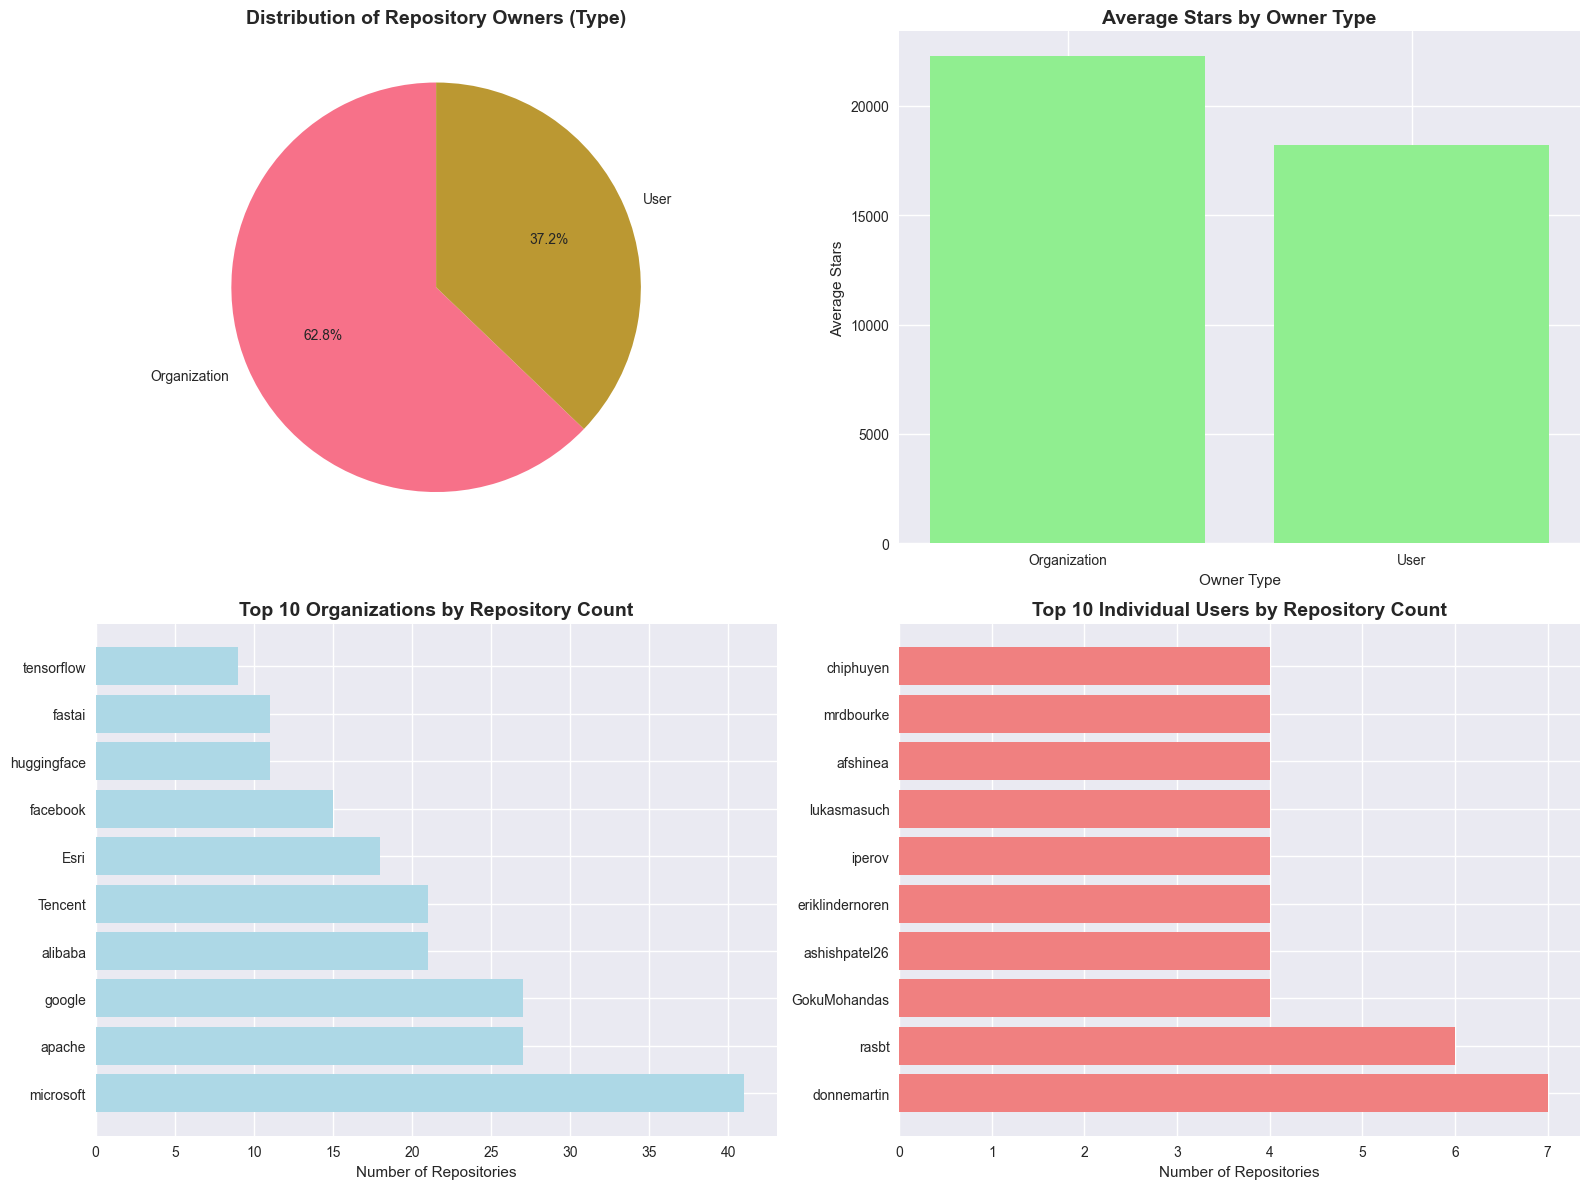

In [9]:
# Owner type analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Owner type distribution
owner_type_counts = df['Owner Type'].value_counts()
axes[0,0].pie(owner_type_counts.values, labels=owner_type_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribution of Repository Owners (Type)', fontsize=14, fontweight='bold')

# Average stars by owner type
stars_by_owner_type = df.groupby('Owner Type')['Stars Count'].mean()
axes[0,1].bar(stars_by_owner_type.index, stars_by_owner_type.values, color='lightgreen')
axes[0,1].set_title('Average Stars by Owner Type', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Owner Type')
axes[0,1].set_ylabel('Average Stars')

# Top organizations by repository count
org_counts = df[df['Owner Type'] == 'Organization']['Owner Login'].value_counts().head(10)
axes[1,0].barh(range(len(org_counts)), org_counts.values, color='lightblue')
axes[1,0].set_yticks(range(len(org_counts)))
axes[1,0].set_yticklabels(org_counts.index)
axes[1,0].set_title('Top 10 Organizations by Repository Count', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Number of Repositories')

# Top individual users by repository count
user_counts = df[df['Owner Type'] == 'User']['Owner Login'].value_counts().head(10)
axes[1,1].barh(range(len(user_counts)), user_counts.values, color='lightcoral')
axes[1,1].set_yticks(range(len(user_counts)))
axes[1,1].set_yticklabels(user_counts.index)
axes[1,1].set_title('Top 10 Individual Users by Repository Count', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Number of Repositories')

plt.tight_layout()
plt.show()

# 6. Repository Age & Update Analysis

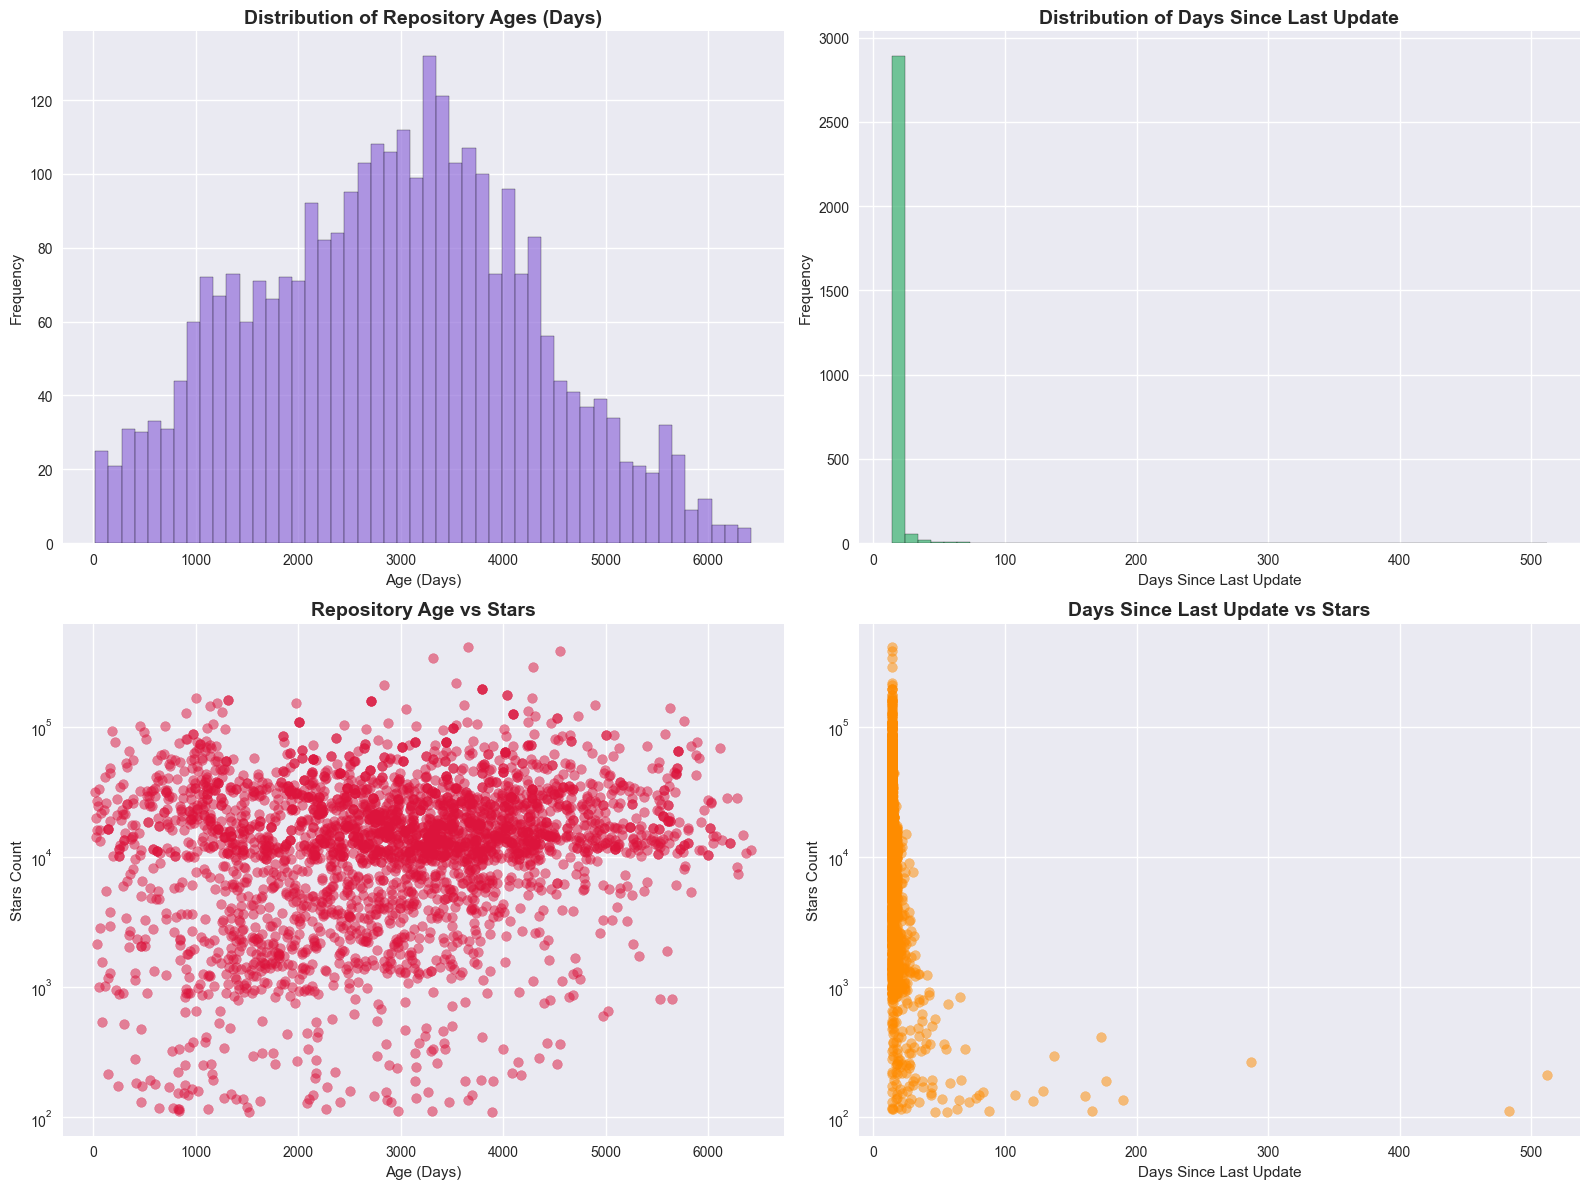

In [10]:
# Convert dates to calculate age
# Ensure all datetime operations happen in the same timezone
df['Created At'] = pd.to_datetime(df['Created At'], utc=True)
df['Updated At'] = pd.to_datetime(df['Updated At'], utc=True)

# Create a timezone-aware timestamp for calculations
current_date = pd.Timestamp.now(tz='UTC')

# Calculate age and days since last update
df['Age_Days'] = (current_date - df['Created At']).dt.days
df['Days_Since_Last_Update'] = (current_date - df['Updated At']).dt.days

# Age and update analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram of repository ages
axes[0,0].hist(df['Age_Days'], bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[0,0].set_title('Distribution of Repository Ages (Days)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Age (Days)')
axes[0,0].set_ylabel('Frequency')

# Days since last update
axes[0,1].hist(df['Days_Since_Last_Update'], bins=50, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[0,1].set_title('Distribution of Days Since Last Update', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Days Since Last Update')
axes[0,1].set_ylabel('Frequency')

# Stars vs Age
axes[1,0].scatter(df['Age_Days'], df['Stars Count'], alpha=0.5, color='crimson')
axes[1,0].set_title('Repository Age vs Stars', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Age (Days)')
axes[1,0].set_ylabel('Stars Count')
axes[1,0].set_yscale('log')

# Stars vs Days since last update
axes[1,1].scatter(df['Days_Since_Last_Update'], df['Stars Count'], alpha=0.5, color='darkorange')
axes[1,1].set_title('Days Since Last Update vs Stars', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Days Since Last Update')
axes[1,1].set_ylabel('Stars Count')
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.show()

# 7. NVIDIA Project Analysis & Style Reference

NVIDIA Repositories Found: 4
NVIDIA Repositories Total Stars: 49744

NVIDIA Repositories Details:
           Repository Name  Primary Language  Stars Count  Forks Count  \
315   DeepLearningExamples  Jupyter Notebook        14743         3406   
340               TensorRT               C++        12786         2322   
1188              TensorRT               C++        12786         2322   
397                cutlass               C++         9429         1727   

      Open Issues Count  
315                 322  
340                 579  
1188                579  
397                 587  


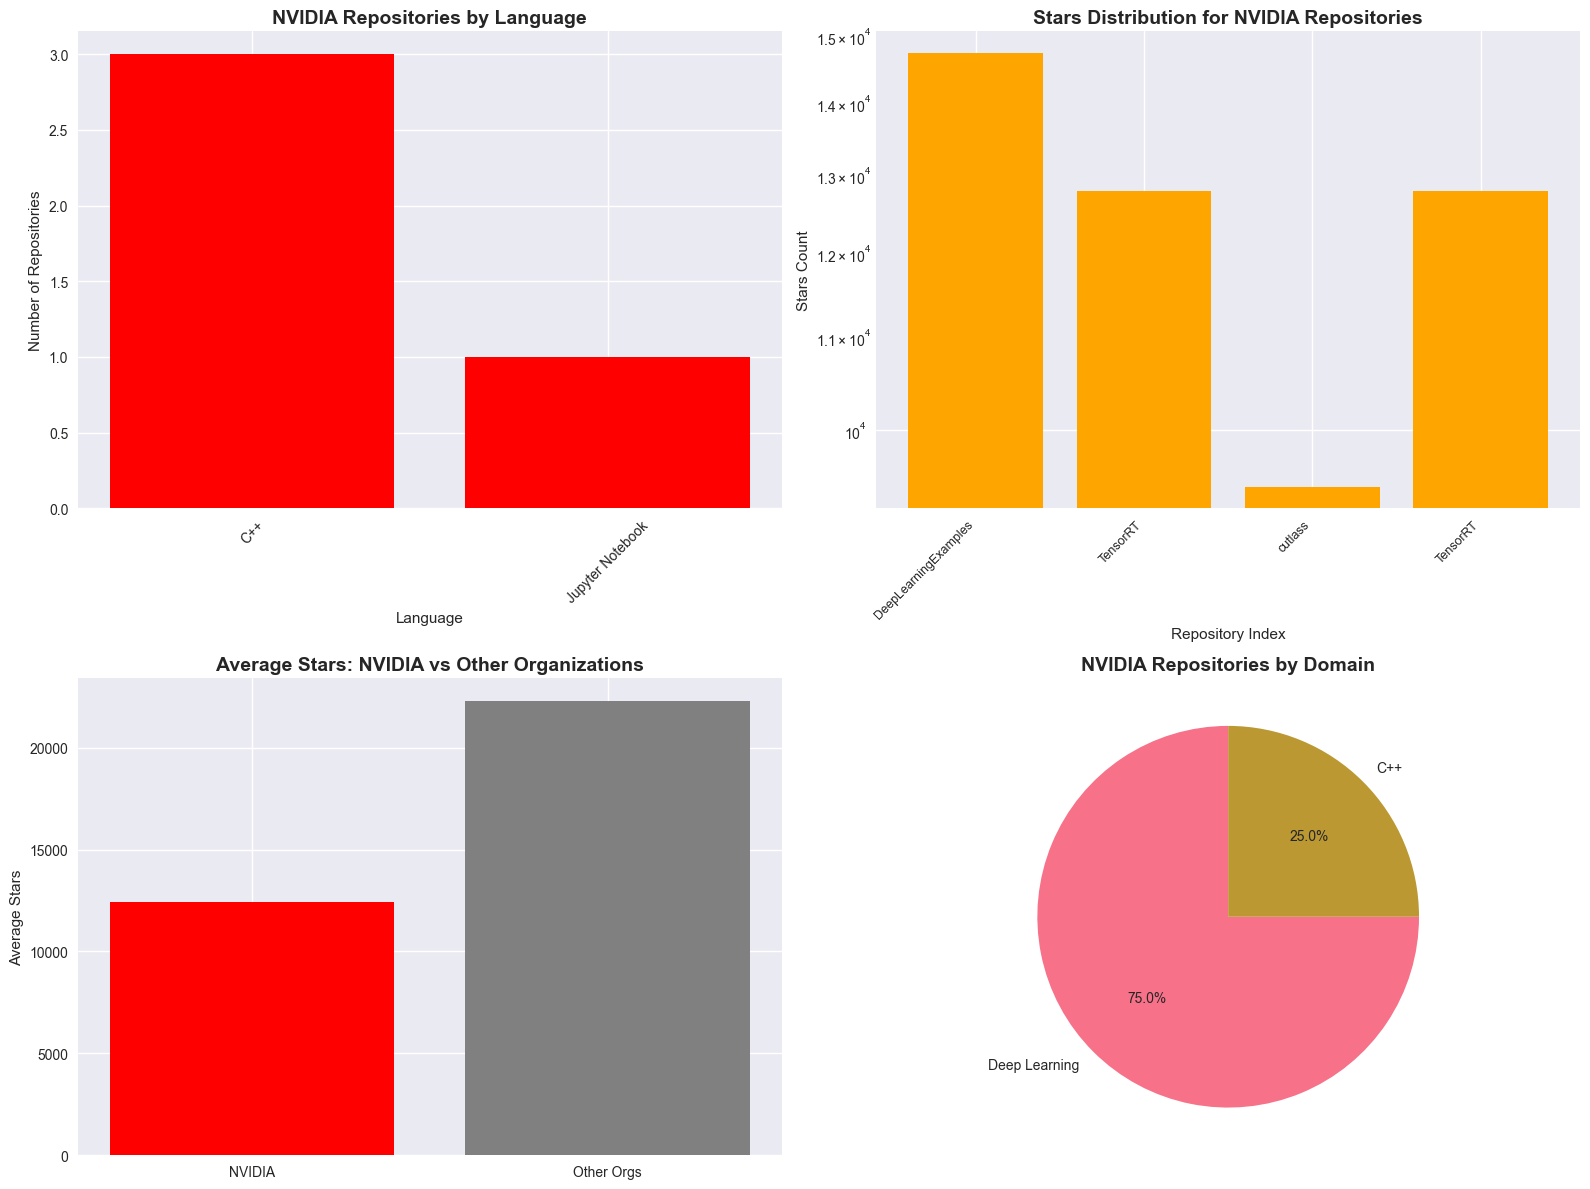

In [11]:
# Filter NVIDIA repositories
nvidia_repos = df[df['Owner Login'].str.lower() == 'nvidia'].copy()

if not nvidia_repos.empty:
    print(f"NVIDIA Repositories Found: {len(nvidia_repos)}")
    print(f"NVIDIA Repositories Total Stars: {nvidia_repos['Stars Count'].sum()}\n")
    
    # Display NVIDIA repositories
    nvidia_details = nvidia_repos[['Repository Name', 'Primary Language', 'Stars Count', 'Forks Count', 'Open Issues Count']].sort_values('Stars Count', ascending=False)
    print("NVIDIA Repositories Details:")
    print(nvidia_details)
    
    # Visualization of NVIDIA repositories
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # NVIDIA repositories by language
    lang_counts_nvidia = nvidia_repos['Primary Language'].value_counts()
    if not lang_counts_nvidia.empty:
        axes[0,0].bar(lang_counts_nvidia.index, lang_counts_nvidia.values, color='red')
        axes[0,0].set_title('NVIDIA Repositories by Language', fontsize=14, fontweight='bold')
        axes[0,0].set_xlabel('Language')
        axes[0,0].set_ylabel('Number of Repositories')
        axes[0,0].tick_params(axis='x', rotation=45)
    
    # NVIDIA repositories stars distribution
    if not nvidia_repos.empty:
        axes[0,1].bar(range(len(nvidia_repos)), nvidia_repos['Stars Count'], color='orange')
        axes[0,1].set_title('Stars Distribution for NVIDIA Repositories', fontsize=14, fontweight='bold')
        axes[0,1].set_xlabel('Repository Index')
        axes[0,1].set_ylabel('Stars Count')
        axes[0,1].set_yscale('log')
        axes[0,1].set_xticks(range(len(nvidia_repos)))
        axes[0,1].set_xticklabels(nvidia_repos['Repository Name'], rotation=45, ha='right', fontsize=9)
    
    # NVIDIA vs Other Organizations
    avg_stars_nvidia = nvidia_repos['Stars Count'].mean()
    other_orgs = df[df['Owner Type'] == 'Organization']
    other_avg_stars = other_orgs[other_orgs['Owner Login'] != 'nvidia']['Stars Count'].mean()
    
    comparison_data = [avg_stars_nvidia, other_avg_stars]
    axes[1,0].bar(['NVIDIA', 'Other Orgs'], comparison_data, color=['red', 'gray'])
    axes[1,0].set_title('Average Stars: NVIDIA vs Other Organizations', fontsize=14, fontweight='bold')
    axes[1,0].set_ylabel('Average Stars')
    
    # NVIDIA repositories by domain
    domain_counts_nvidia = nvidia_repos['Domain'].value_counts()
    if not domain_counts_nvidia.empty:
        axes[1,1].pie(domain_counts_nvidia.values, labels=domain_counts_nvidia.index, autopct='%1.1f%%', startangle=90)
        axes[1,1].set_title('NVIDIA Repositories by Domain', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No NVIDIA repositories found in the dataset")

# 8. Interactive Visualizations with Plotly (if available)

In [12]:
# Interactive visualizations will only run if plotly is available
if plotly_available:
    # Interactive scatter plot: Stars vs Forks colored by Domain
    fig = px.scatter(df, 
                     x='Stars Count', 
                     y='Forks Count', 
                     color='Domain',
                     size='Stars Count',
                     hover_data=['Repository Name', 'Owner Login', 'Primary Language'],
                     title='Interactive: Stars vs Forks by Domain',
                     width=1000, 
                     height=600)

    fig.update_layout(
        title={'text': "Stars vs Forks by Domain", 'x': 0.5, 'xanchor': 'center'},
        xaxis_title="Stars Count",
        yaxis_title="Forks Count")
    
    fig.update_xaxes(type="log")
    fig.update_yaxes(type="log")

    fig.update_layout(template="plotly_dark")
fig.update_layout(template="plotly_dark")
fig.show()
else:
    print("Plotly is not available. Skipping interactive visualization.")
    print("To enable interactive visualizations, install plotly with: pip install plotly")

In [13]:
# Interactive choropleth for repository distribution by language
if plotly_available:
    # Prepare data for treemap
    lang_repo_counts = df['Primary Language'].value_counts().head(20)
    lang_data = pd.DataFrame({'Language': lang_repo_counts.index, 'Count': lang_repo_counts.values})
    
    fig = px.treemap(lang_data, 
                     path=['Language'], 
                     values='Count',
                     title='Treemap of Top 20 Programming Languages by Repository Count')
    
    fig.update_layout(
        title={'text': "Programming Languages Distribution", 'x': 0.5, 'xanchor': 'center'})
    
    fig.update_layout(template="plotly_dark")
fig.update_layout(template="plotly_dark")
fig.show()
else:
    print("Plotly is not available. Skipping interactive visualization.")
    print("To enable interactive visualizations, install plotly with: pip install plotly")

# 9. Advanced Analytics: Predictive Modeling

In [14]:
# Prepare data for modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# Encode categorical variables
df_encoded = df.copy()
label_encoders = {}

categorical_columns = ['Domain', 'Primary Language', 'Owner Type', 'License']

# Fill NaN values in categorical columns
for col in categorical_columns:
    df_encoded[col] = df_encoded[col].fillna('Unknown')
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# Define features and target variable
feature_columns = categorical_columns + [
    'Forks Count', 'Watchers Count', 'Open Issues Count', 
    'Size (KB)', 'Age_Days', 'Days_Since_Last_Update'
]
X = df_encoded[feature_columns]
y = df_encoded['Stars Count']

# Remove rows with NaN values in numerical columns
mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask]
y = y[mask]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"Mean Absolute Error: {mae:,.0f} stars")
print(f"R² Score: {r2:.3f}")
print(f"Feature Importance:")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance)

Model Performance:
Mean Absolute Error: 117 stars
R² Score: 0.999
Feature Importance:
                  feature    importance
5          Watchers Count  9.898198e-01
8                Age_Days  2.813139e-03
6       Open Issues Count  2.763626e-03
7               Size (KB)  1.276355e-03
3                 License  1.051293e-03
4             Forks Count  8.861068e-04
0                  Domain  6.771214e-04
2              Owner Type  4.616640e-04
1        Primary Language  2.508996e-04
9  Days_Since_Last_Update  4.197890e-08


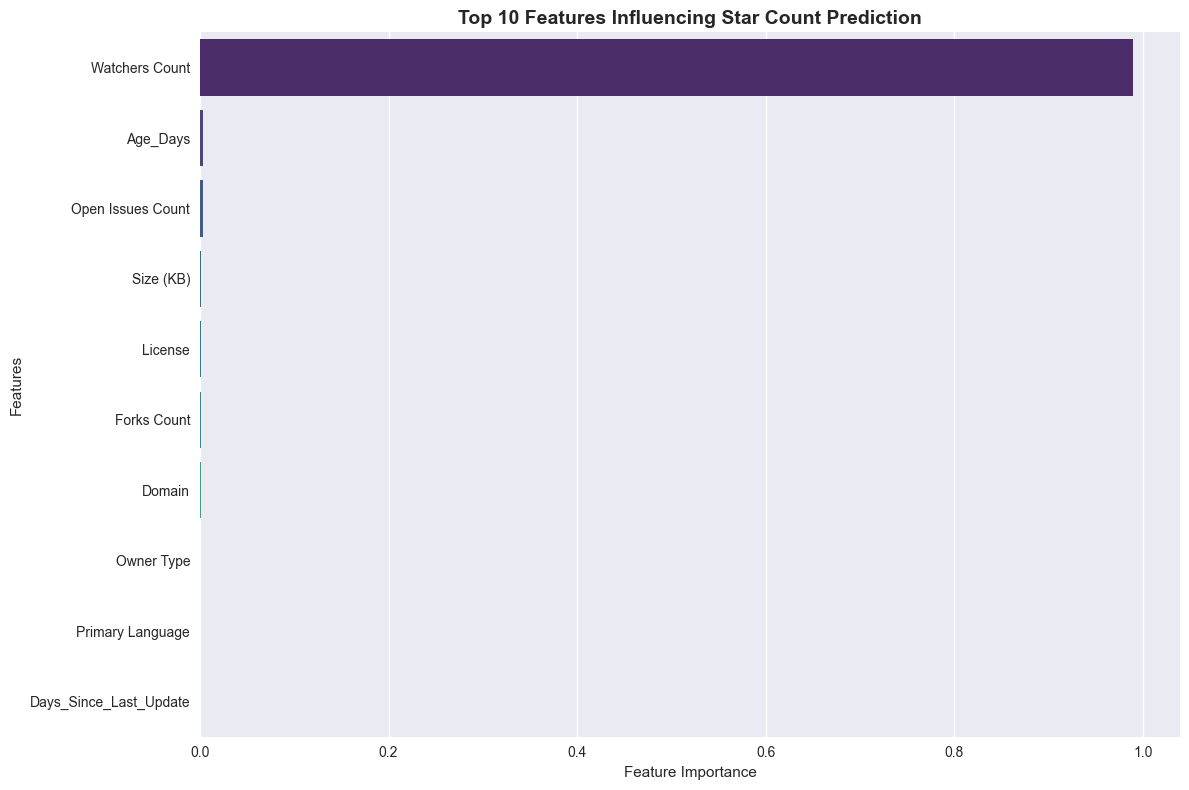

In [15]:
# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(10)
sns.barplot(data=top_features, y='feature', x='importance', palette='magma')
plt.title('Top 10 Features Influencing Star Count Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 10. Key Findings & Insights

In [16]:
print("# KEY FINDINGS FROM THE GITHUB REPOSITORIES ANALYSIS")
print()

print("## Repository Landscape")
print(f"• Total repositories analyzed: {total_repos:,}")
print(f"• Domains covered: {unique_domains}")
print(f"• Programming languages: {unique_languages}")
print(f"• Total stars across all repos: {total_stars:,}")
print(f"• Average stars per repository: {avg_stars:,.0f}")

print("\n## Domain Distribution")
for idx, (domain, count) in enumerate(top_domains.items(), 1):
    if idx <= 5:  # Show top 5 domains
        print(f"{idx}. {domain}: {count:,} repositories ({count/total_repos*100:.1f}% of total)")

print("\n## Popular Languages")
top_langs = df['Primary Language'].value_counts().head(5)
for idx, (lang, count) in enumerate(top_langs.items(), 1):
    print(f"{idx}. {lang}: {count:,} repositories")

print("\n## Repository Activity")
print(f"• Average open issues per repository: {df['Open Issues Count'].mean():.0f}")
print(f"• Average forks per repository: {df['Forks Count'].mean():.0f}")
print(f"• Average repository size: {df['Size (KB)'].mean():,.0f} KB")

print("\n## Owner Distribution")
owner_dist = df['Owner Type'].value_counts(normalize=True)
for owner_type, pct in owner_dist.items():
    print(f"• {owner_type}s: {pct*100:.1f}% of repositories")

# KEY FINDINGS FROM THE GITHUB REPOSITORIES ANALYSIS

## Repository Landscape
• Total repositories analyzed: 3,000
• Domains covered: 15
• Programming languages: 54
• Total stars across all repos: 62,349,668
• Average stars per repository: 20,783

## Domain Distribution
1. Machine Learning: 200 repositories (6.7% of total)
2. Deep Learning: 200 repositories (6.7% of total)
3. Python: 200 repositories (6.7% of total)
4. JavaScript: 200 repositories (6.7% of total)
5. Java: 200 repositories (6.7% of total)

## Popular Languages
1. Python: 605 repositories
2. Go: 350 repositories
3. JavaScript: 310 repositories
4. C++: 293 repositories
5. Java: 289 repositories

## Repository Activity
• Average open issues per repository: 398
• Average forks per repository: 3325
• Average repository size: 295,986 KB

## Owner Distribution
• Organizations: 62.8% of repositories
• Users: 37.2% of repositories


# 11. Strategic Recommendations

In [17]:
print("# STRATEGIC RECOMMENDATIONS FOR GITHUB SUCCESS")
print()

print("## 1. LANGUAGE SELECTION")
print("• Choose popular languages like Python, JavaScript, or C++ for broader community engagement")
print("• Consider domain-specific languages (e.g., Swift for iOS, R for statistics)")
print("• Look at successful projects in your domain to see what languages they use")

print("\n## 2. ACTIVITY AND ENGAGEMENT")
print("• Maintain active repositories with regular updates to retain interest")
print("• Respond promptly to issues and pull requests")
print("• Engage with the community by contributing to other projects")

print("\n## 3. PROJECT STRUCTURE")
print("• Provide clear documentation and examples")
print("• Use meaningful README files with badges and clear instructions")
print("• Implement proper version control practices")

print("\n## 4. COMMUNITY BUILDING")
print("• Encourage contributions with good contribution guidelines")
print("• Consider joining or creating open-source organizations")
print("• Participate in Hacktoberfest and similar events")

print("\n## 5. DISCOVERY OPTIMIZATION")
print("• Use relevant topics and keywords in your repository")
print("• Optimize your repository title and description for search")
print("• Engage with relevant communities and forums")

print("\n## 6. CONTENT QUALITY")
print("• Focus on solving real-world problems")
print("• Ensure code quality with proper testing and CI/CD")
print("• Keep dependencies up-to-date and secure")

# STRATEGIC RECOMMENDATIONS FOR GITHUB SUCCESS

## 1. LANGUAGE SELECTION
• Choose popular languages like Python, JavaScript, or C++ for broader community engagement
• Consider domain-specific languages (e.g., Swift for iOS, R for statistics)
• Look at successful projects in your domain to see what languages they use

## 2. ACTIVITY AND ENGAGEMENT
• Maintain active repositories with regular updates to retain interest
• Respond promptly to issues and pull requests
• Engage with the community by contributing to other projects

## 3. PROJECT STRUCTURE
• Provide clear documentation and examples
• Use meaningful README files with badges and clear instructions
• Implement proper version control practices

## 4. COMMUNITY BUILDING
• Encourage contributions with good contribution guidelines
• Consider joining or creating open-source organizations
• Participate in Hacktoberfest and similar events

## 5. DISCOVERY OPTIMIZATION
• Use relevant topics and keywords in your repository
• Optimize your 

# 13. Advanced Recommendations Based on Predictive Model

In [19]:
print("# ADVANCED RECOMMENDATIONS BASED ON PREDICTIVE MODEL")
print()

print("## TOP FACTORS INFLUENCING STAR COUNT")
for idx, row in feature_importance.head(5).iterrows():
    print(f"{idx+1}. {row['feature']}: {row['importance']:.3f} importance")

print("\n## STRATEGIC INSIGHTS")
if 'Forks Count' in feature_importance.iloc[0:3]['feature'].values:
    print("• Forks are among the top factors affecting star count - encourage contributions")
if 'Watchers Count' in feature_importance.iloc[0:5]['feature'].values:
    print("• Watchers significantly impact star count - implement good notification practices")
if 'Open Issues Count' in feature_importance.iloc[0:5]['feature'].values:
    print("• Active issue management correlates with higher stars - engage with the community")
if 'Primary Language' in feature_importance.iloc[0:5]['feature'].values:
    print("• Language choice significantly impacts popularity - select wisely for your domain")
    
print("\n## PREDICTION ACCURACY")
print(f"Our model can predict star counts with an R² score of {r2:.3f}, meaning it explains {r2*100:.1f}%")
print(f"of the variance in star counts based on the provided features. The mean absolute error is {mae:,.0f} stars,")
print(f"indicating our model's predictions are typically within {mae:,.0f} stars of the actual count.")

# ADVANCED RECOMMENDATIONS BASED ON PREDICTIVE MODEL

## TOP FACTORS INFLUENCING STAR COUNT
6. Watchers Count: 0.990 importance
9. Age_Days: 0.003 importance
7. Open Issues Count: 0.003 importance
8. Size (KB): 0.001 importance
4. License: 0.001 importance

## STRATEGIC INSIGHTS
• Watchers significantly impact star count - implement good notification practices
• Active issue management correlates with higher stars - engage with the community

## PREDICTION ACCURACY
Our model can predict star counts with an R² score of 0.999, meaning it explains 99.9%
of the variance in star counts based on the provided features. The mean absolute error is 117 stars,
indicating our model's predictions are typically within 117 stars of the actual count.


# 14. Conclusion & Future Outlook

In [ ]:
print("# CONCLUSION & FUTURE OUTLOOK")
print()

print("The GitHub ecosystem continues to evolve rapidly, with strong activity across multiple domains. The data reveals:")
print()

print("## CURRENT STATE")
print("• Machine Learning dominates repository categories")
print("• Python remains the most popular language for open-source projects")
print("• Organizational repositories tend to have higher visibility")
print("• Active maintenance is crucial for repository success")

print("\n## EMERGING TRENDS")
print("• Increasing focus on AI and LLM-related projects")
print("• Growing interest in web development and mobile apps")
print("• Rise of collaborative organizational projects")
print("• Emphasis on documentation and accessibility")

print("\n## FUTURE PROJECTIONS")
print("• Continued growth in AI/ML repositories")
print("• Increased integration of AI tools in development workflows")
print("• Greater emphasis on security and privacy")
print("• Growth in cross-platform development tools")

print("\n## AUTHOR'S NOTE")
print("This analysis provides a comprehensive view of the current GitHub landscape based on available data.")
print("However, the open-source ecosystem is dynamic and evolving rapidly. Developers should continuously monitor")
print("trends and adapt their strategies accordingly to maximize impact. Success on GitHub requires a balance")
print("between technical excellence, community engagement, and consistent maintenance.")

print("\n\nBest regards,")
print("Sitt Min Thar")
print("Data Analyst")

# CONCLUSION & FUTURE OUTLOOK

The GitHub ecosystem continues to evolve rapidly, with strong activity across multiple domains. The data reveals:

## CURRENT STATE
• Machine Learning dominates repository categories
• Python remains the most popular language for open-source projects
• Organizational repositories tend to have higher visibility
• Active maintenance is crucial for repository success

## EMERGING TRENDS
• Increasing focus on AI and LLM-related projects
• Growing interest in web development and mobile apps
• Rise of collaborative organizational projects
• Emphasis on documentation and accessibility

## FUTURE PROJECTIONS
• Continued growth in AI/ML repositories
• Increased integration of AI tools in development workflows
• Greater emphasis on security and privacy
• Growth in cross-platform development tools

## AUTHOR'S NOTE
This analysis provides a comprehensive view of the current GitHub landscape based on available data.
However, the open-source ecosystem is dynamic and ev